##  **Задача 1: Прогноз времени доставки заказов**

**Контекст:**
Онлайн-магазин хочет предсказать время доставки заказа клиенту, чтобы оптимизировать логистику.

### **Данные:**

| Расстояние (км) | Вес заказа (кг) | Курьер (тип) | Время суток | Город доставки | Срочность | Время доставки (мин) |
| --------------- | --------------- | ------------ | ----------- | -------------- | --------- | -------------------- |
| 12              | 2.5             | Пеший        | Утро        | Москва         | Высокая   | 45                   |
| 60              | 10              | Авто         | Вечер       | СПб            | Средняя   | 90                   |
| ...             | ...             | ...          | ...         | ...            | ...       | ...                  |

### **Особенности задачи:**

* Пропущены значения в "Вес заказа", "Время суток", "Срочность"
* **Целевая переменная:** `Время доставки`
* **Задача:** линейная регрессия

### **Что необходимо сделать:**

1. Обработка пропущенных значений

   * Числовые: медиана
   * Категориальные: мода

2.  Масштабирование числовых признаков (`StandardScaler`)

3.  Кодирование категориальных признаков:

   * `OneHotEncoder` для "Курьер", "Время суток", "Город доставки", "Срочность"

4.  Отбор признаков:

   * `SelectFromModel` или `RFE` с `LinearRegression` — убрать малозначимые

5.  Уменьшение размерности:

   * PCA — визуализация типов доставки по кластерам

6.  Линейная регрессия: прогноз времени доставки

Первые строки данных:
   Расстояние  Вес заказа     Курьер Время суток Город доставки Срочность  \
0          12         2.5      Пеший        Утро         Москва   Высокая   
1          60        10.0       Авто       Вечер            СПб   Средняя   
2          30         5.2  Велосипед         NaN         Москва    Низкая   
3           7         NaN      Пеший        Утро         Казань   Высокая   
4         100        20.0       Авто        День            СПб   Средняя   

   Время доставки  
0              45  
1              90  
2              60  
3              30  
4             120  


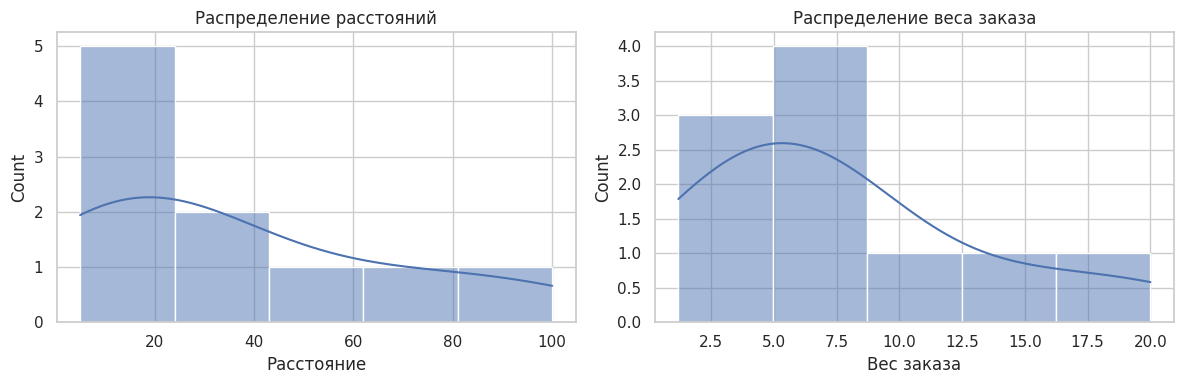

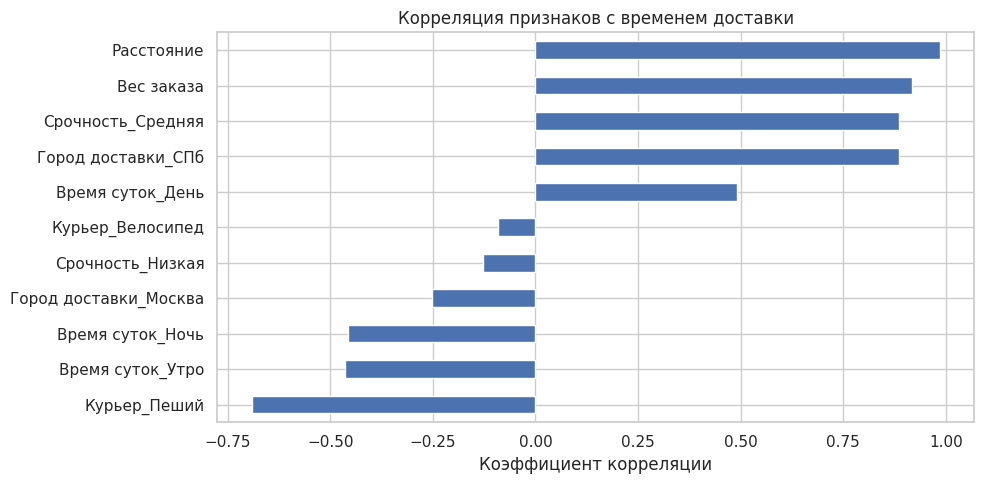

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


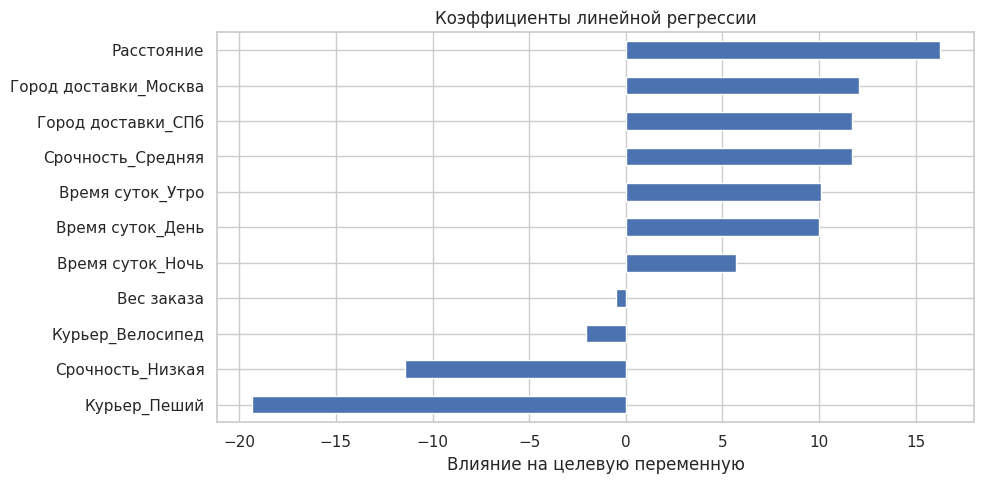

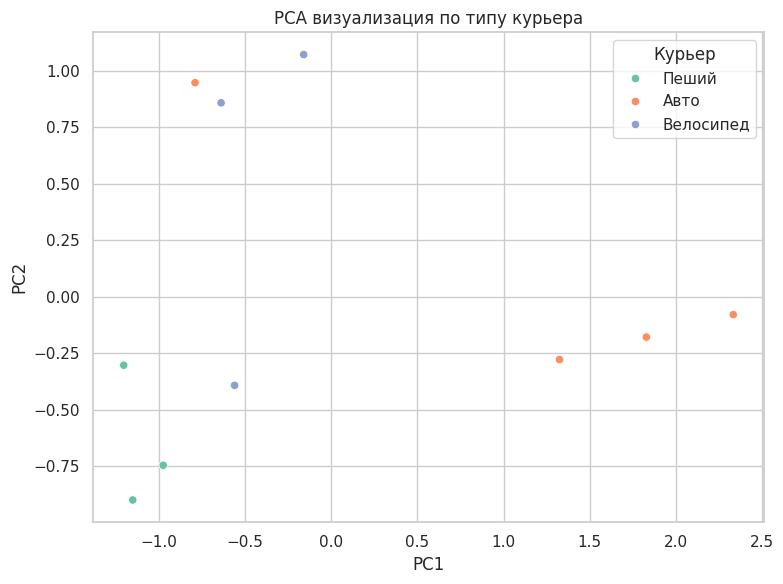

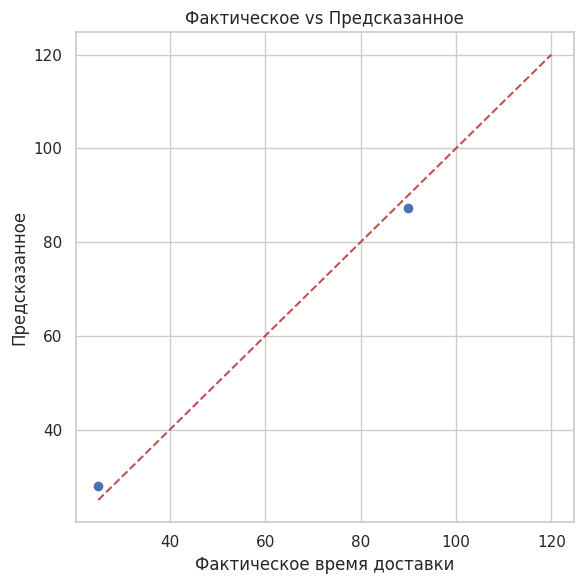


Метрики качества модели:
MAE: 2.7804878048780495
MSE: 7.74063057703748
R²: 0.9926715923531007


In [ ]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
sns.set(style="whitegrid")

# 1. Загрузка данных
data = pd.DataFrame({
    'Расстояние': [12, 60, 30, 7, 100, 22, 15, 80, 5, 40],
    'Вес заказа': [2.5, 10, 5.2, np.nan, 20, 7.5, 3.3, 15, 1.2, np.nan],
    'Курьер': ['Пеший', 'Авто', 'Велосипед', 'Пеший', 'Авто', 'Велосипед', 'Авто', 'Авто', 'Пеший', 'Велосипед'],
    'Время суток': ['Утро', 'Вечер', np.nan, 'Утро', 'День', 'Утро', 'Ночь', 'Вечер', 'Ночь', 'День'],
    'Город доставки': ['Москва', 'СПб', 'Москва', 'Казань', 'СПб', 'Казань', 'Москва', 'СПб', 'Казань', 'Москва'],
    'Срочность': ['Высокая', 'Средняя', 'Низкая', 'Высокая', 'Средняя', np.nan, 'Низкая', 'Средняя', 'Высокая', 'Низкая'],
    'Время доставки': [45, 90, 60, 30, 120, 55, 50, 100, 25, 65]
})

print("Первые строки данных:")
print(data.head())


# 2. Обработка пропущенных значений
num_cols = ['Вес заказа']
cat_cols = ['Время суток', 'Срочность']

# Импьютеры
data[num_cols] = SimpleImputer(strategy='median').fit_transform(data[num_cols])
data[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(data[cat_cols])


# Визуализация распределений
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data['Расстояние'], kde=True)
plt.title("Распределение расстояний")

plt.subplot(1, 2, 2)
sns.histplot(data['Вес заказа'], kde=True)
plt.title("Распределение веса заказа")
plt.tight_layout()
plt.show()


# 3. Масштабирование числовых признаков
scale_cols = ['Расстояние', 'Вес заказа']
data[scale_cols] = StandardScaler().fit_transform(data[scale_cols])


# 4. OneHot-кодирование категориальных признаков
ohe_cols = ['Курьер', 'Время суток', 'Город доставки', 'Срочность']
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_ohe = ohe.fit_transform(data[ohe_cols])
encoded_ohe_df = pd.DataFrame(encoded_ohe, columns=ohe.get_feature_names_out(ohe_cols))

X = pd.concat([data[scale_cols], encoded_ohe_df], axis=1)
y = data['Время доставки']


# Корреляция признаков с целевой переменной
corr_df = pd.concat([X, y], axis=1)
correlations = corr_df.corr(numeric_only=True)['Время доставки'].drop('Время доставки')

plt.figure(figsize=(10, 5))
correlations.sort_values().plot(kind='barh')
plt.title("Корреляция признаков с временем доставки")
plt.xlabel("Коэффициент корреляции")
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Отбор признаков (LinearRegression + SelectFromModel)
model = LinearRegression().fit(X, y)
selector = SelectFromModel(estimator=model, threshold='mean', prefit=True)
X_selected = selector.transform(X)
selected_features = X.columns[selector.get_support()]


# Важность признаков (по коэффициентам)
coef_series = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(10, 5))
coef_series.sort_values().plot(kind='barh')
plt.title("Коэффициенты линейной регрессии")
plt.xlabel("Влияние на целевую переменную")
plt.grid(True)
plt.tight_layout()
plt.show()


# 6. PCA визуализация по выбранным признакам
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Курьер'] = data['Курьер']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Курьер', palette='Set2')
plt.title('PCA визуализация по типу курьера')
plt.grid(True)
plt.tight_layout()
plt.show()


# 7. Обучение и оценка линейной регрессии
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
final_model = LinearRegression().fit(X_train, y_train)
y_pred = final_model.predict(X_test)


# Визуализация: предсказания vs факты
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Фактическое время доставки")
plt.ylabel("Предсказанное")
plt.title("Фактическое vs Предсказанное")
plt.grid(True)
plt.tight_layout()
plt.show()


# Метрики качества
print("\nМетрики качества модели:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

## **Задача 2: Прогноз дохода по данным о домохозяйствах**

**Контекст:**
Агентство по социальной политике собирает данные о семьях для оценки уровня дохода и выявления групп риска. По характеристикам семьи нужно предсказать её средний ежемесячный доход.

### **Данные:**

| Число членов семьи | Образование главы | Кол-во работающих | Регион | Общие расходы | Есть авто | Доход (целевая) |
| ------------------ | ----------------- | ----------------- | ------ | ------------- | --------- | --------------- |
| 4                  | Высшее            | 2                 | Центр  | 75000         | Да        | 120000          |
| 2                  | Среднее           | 1                 | Юг     | 35000         | Нет       | 60000           |
| ...                | ...               | ...               | ...    | ...           | ...       | ...             |

### **Особенности задачи:**

* Есть пропущенные значения в "Образование главы", "Общие расходы", "Есть авто".
* **Целевая переменная:** `Доход`
* **Задача:** линейная регрессия

### **Что необходимо сделать:**

1.  Обработка пропущенных значений

   * Числовые → медиана, категориальные → мода

2.  Масштабирование/нормализация числовых признаков (`StandardScaler` или `MinMaxScaler`)

3.  Кодирование категориальных данных:

   * `OneHotEncoder` для "Регион", "Образование главы", "Есть авто"

4.  Отбор признаков:

   * Использование `SelectKBest` или `RFE` (например, с `LinearRegression`) для выбора наиболее влияющих факторов

5.  Уменьшение размерности:

   * PCA (например, до 2 компонент) — визуализация семейных типов и распределения доходов

6.  Построение и обучение линейной регрессионной модели







Исходные данные:
    Число членов семьи     Образование главы  Кол-во работающих  Регион  \
0                 4.0                Высшее                2.0   Центр   
1                 2.0               Среднее                1.0      Юг   
2                 5.0                   NaN                3.0   Север   
3                 3.0  Незаконченное высшее                1.0     NaN   
4                 NaN               Среднее                2.0   Центр   
5                 6.0                Высшее                NaN  Восток   
6                 3.0  Незаконченное высшее                1.0      Юг   
7                 4.0               Среднее                2.0   Север   
8                 2.0                Высшее                0.0   Центр   
9                 5.0                   NaN                3.0   Запад   

   Общие расходы Есть авто   Доход  
0        75000.0        Да  120000  
1        35000.0       Нет   60000  
2        90000.0        Да  150000  
3        45000.0   

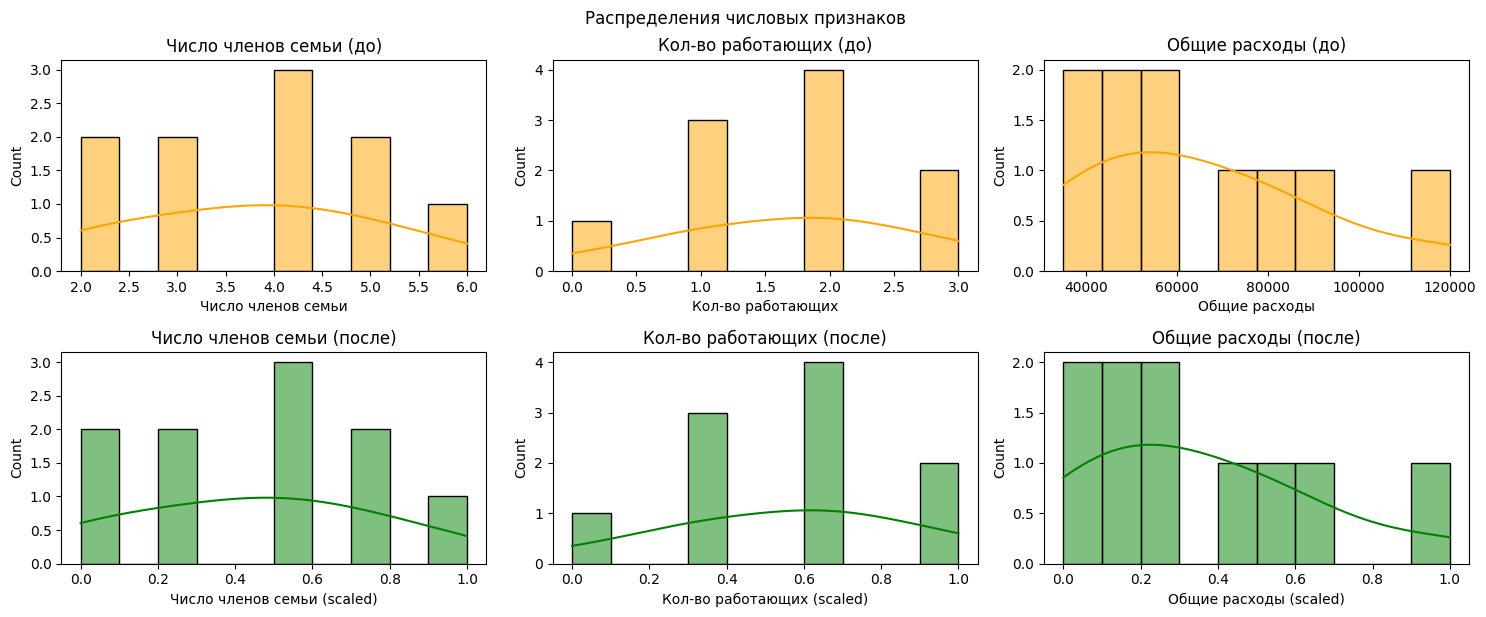

One-Hot закодированные признаки:
    Образование главы_Незаконченное высшее  Образование главы_Среднее  \
0                                     0.0                        0.0   
1                                     0.0                        1.0   
2                                     0.0                        0.0   
3                                     1.0                        0.0   
4                                     0.0                        1.0   

   Регион_Запад  Регион_Север  Регион_Центр  Регион_Юг  Есть авто_Нет  
0           0.0           0.0           1.0        0.0            0.0  
1           0.0           0.0           0.0        1.0            1.0  
2           0.0           1.0           0.0        0.0            0.0  
3           0.0           0.0           1.0        0.0            0.0  
4           0.0           0.0           1.0        0.0            0.0   

Размерность признаков: (10, 10)


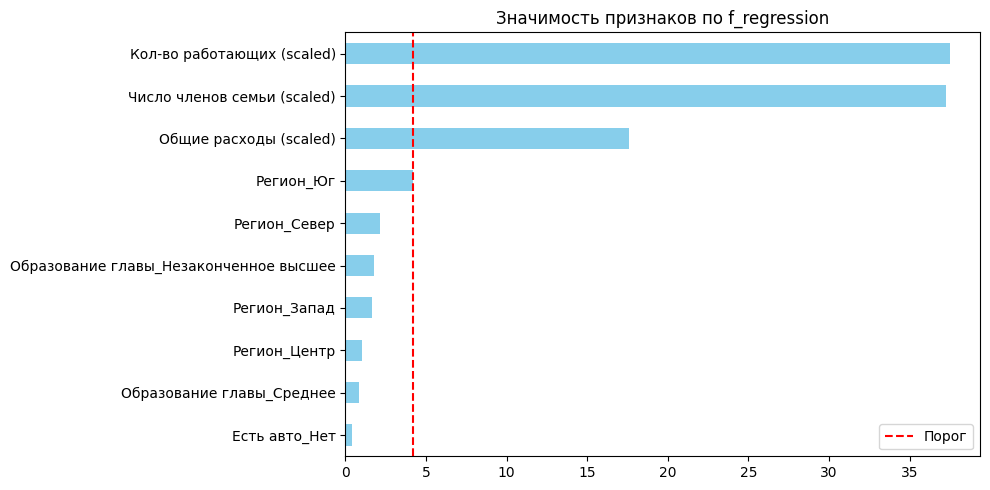

Выбранные признаки:
 ['Число членов семьи (scaled)', 'Кол-во работающих (scaled)', 'Общие расходы (scaled)', 'Регион_Юг'] 

Объясненная дисперсия PCA: [0.68723025 0.23595185]


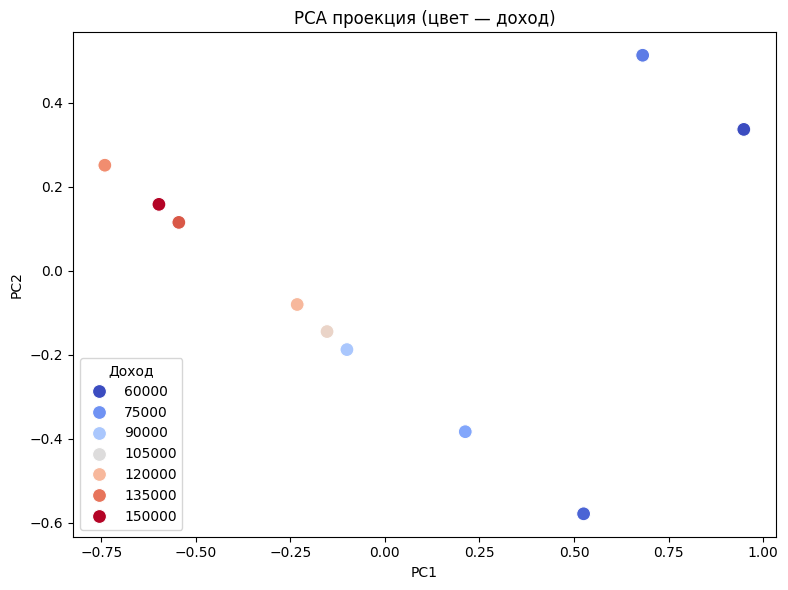

Модель на отобранных признаках
R^2: 0.9942
Коэффициенты:
 Число членов семьи (scaled)    -90830.860534
Кол-во работающих (scaled)      94740.356083
Общие расходы (scaled)         100007.418398
Регион_Юг                      -28419.881306
dtype: float64 

Модель на PCA-признаках
R^2: 0.9201
Коэффициенты:
 PC1   -53803.862648
PC2    17551.861567
dtype: float64 



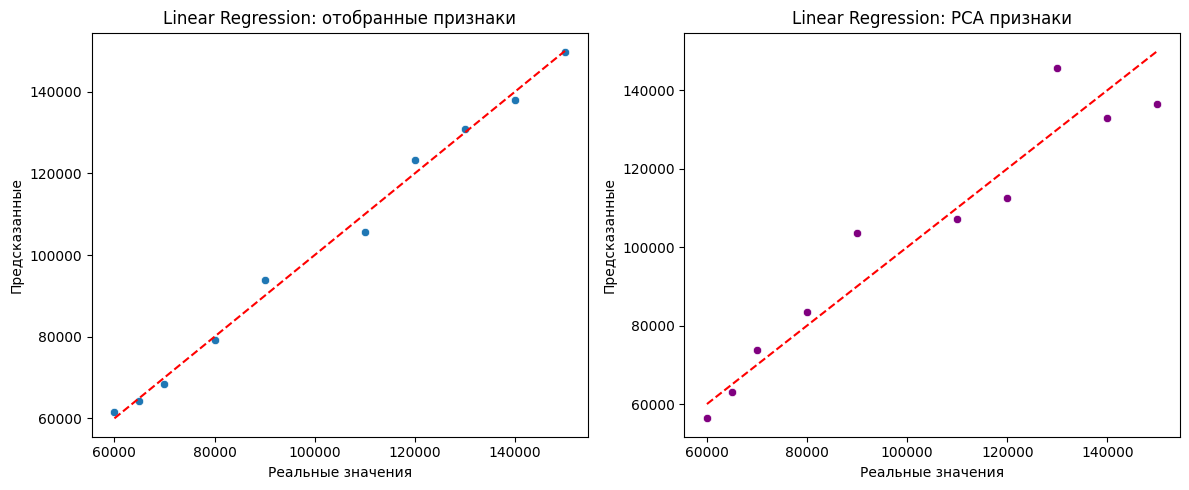

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Синтетические данные
data1 = pd.DataFrame({
    'Число членов семьи':    [4, 2, 5,   3,   np.nan, 6, 3, 4, 2, 5],
    'Образование главы':     ['Высшее', 'Среднее', np.nan, 'Незаконченное высшее',
                              'Среднее', 'Высшее', 'Незаконченное высшее', 'Среднее', 'Высшее', np.nan],
    'Кол-во работающих':     [2, 1, 3,   1,   2,       np.nan, 1, 2, 0, 3],
    'Регион':                ['Центр', 'Юг', 'Север', np.nan, 'Центр', 'Восток', 'Юг', 'Север', 'Центр', 'Запад'],
    'Общие расходы':         [75000, 35000, 90000, 45000, 50000, 120000, np.nan, 60000, 40000, 80000],
    'Есть авто':             ['Да', 'Нет', 'Да', 'Да', np.nan, 'Нет', 'Да', 'Нет', 'Да', 'Нет'],
    'Доход':                 [120000, 60000, 150000, 80000, 90000, 130000, 70000, 110000, 65000, 140000]
})

print("Исходные данные:\n", data1, "\n")

# 2. Удаление дубликатов
data1 = data1.drop_duplicates()
print("После удаления дубликатов:", data1.shape, "\n")

# 3. Обработка пропусков
num_cols = ['Число членов семьи', 'Кол-во работающих', 'Общие расходы']
cat_cols = ['Образование главы', 'Регион', 'Есть авто']

data1[num_cols] = SimpleImputer(strategy='median').fit_transform(data1[num_cols])
data1[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(data1[cat_cols])

print("После заполнения пропусков:\n", data1.head(), "\n")

# 4. Масштабирование числовых признаков (MinMaxScaler)
scaler = MinMaxScaler()
data1_scaled_num = pd.DataFrame(
    scaler.fit_transform(data1[num_cols]),
    columns=[f"{col} (scaled)" for col in num_cols]
)

# Визуализация до/после масштабирования
fig, axs = plt.subplots(2, len(num_cols), figsize=(15, 6))
for i, col in enumerate(num_cols):
    sns.histplot(data1[col], bins=10, kde=True, ax=axs[0, i], color='orange')
    axs[0, i].set_title(f'{col} (до)')

    sns.histplot(data1_scaled_num[f'{col} (scaled)'], bins=10, kde=True, ax=axs[1, i], color='green')
    axs[1, i].set_title(f'{col} (после)')

plt.tight_layout()
plt.suptitle("Распределения числовых признаков", y=1.02)
plt.show()

# 5. OneHot-кодирование категориальных признаков
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = ohe.fit_transform(data1[cat_cols])
ohe_feature_names = ohe.get_feature_names_out(cat_cols)
data1_encoded_cat = pd.DataFrame(encoded_cats, columns=ohe_feature_names)

print("One-Hot закодированные признаки:\n", data1_encoded_cat.head(), "\n")

# 6. Объединение всех признаков
X_full = pd.concat([data1_scaled_num, data1_encoded_cat], axis=1)
y_full = data1['Доход']
print("Размерность признаков:", X_full.shape)

# 7. SelectKBest (f_regression)
selector = SelectKBest(score_func=f_regression, k=4)
X_selected = selector.fit_transform(X_full, y_full)
selected_features = X_full.columns[selector.get_support()]

# Визуализация значимости признаков
scores = pd.Series(selector.scores_, index=X_full.columns).sort_values()
scores.plot(kind='barh', figsize=(10, 5), color='skyblue')
plt.title("Значимость признаков по f_regression")
plt.axvline(scores[selected_features].min(), color='red', linestyle='--', label='Порог')
plt.legend()
plt.tight_layout()
plt.show()

print("Выбранные признаки:\n", list(selected_features), "\n")

X_sel_df = pd.DataFrame(X_selected, columns=selected_features)

# 8. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sel_df)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Визуализация PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue=y_full, palette='coolwarm', s=100)
plt.title("PCA проекция (цвет — доход)")
plt.tight_layout()
plt.show()

# 9. Линейная регрессия
lr_sel = LinearRegression().fit(X_sel_df, y_full)
y_pred_sel = lr_sel.predict(X_sel_df)

lr_pca = LinearRegression().fit(X_pca, y_full)
y_pred_pca = lr_pca.predict(X_pca)

# R^2 и коэффициенты
print("Модель на отобранных признаках")
print("R^2:", round(r2_score(y_full, y_pred_sel), 4))
print("Коэффициенты:\n", pd.Series(lr_sel.coef_, index=selected_features), "\n")

print("Модель на PCA-признаках")
print("R^2:", round(r2_score(y_full, y_pred_pca), 4))
print("Коэффициенты:\n", pd.Series(lr_pca.coef_, index=['PC1', 'PC2']), "\n")

# Визуализация: предсказанные vs реальные значения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_full, y=y_pred_sel)
plt.plot([y_full.min(), y_full.max()], [y_full.min(), y_full.max()], 'r--')
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные")
plt.title("Linear Regression: отобранные признаки")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_full, y=y_pred_pca, color='purple')
plt.plot([y_full.min(), y_full.max()], [y_full.min(), y_full.max()], 'r--')
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные")
plt.title("Linear Regression: PCA признаки")

plt.tight_layout()
plt.show()